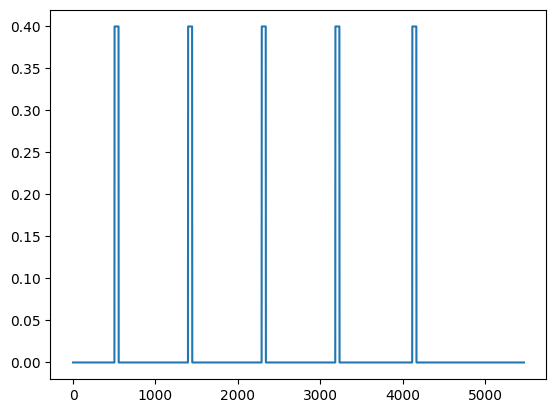

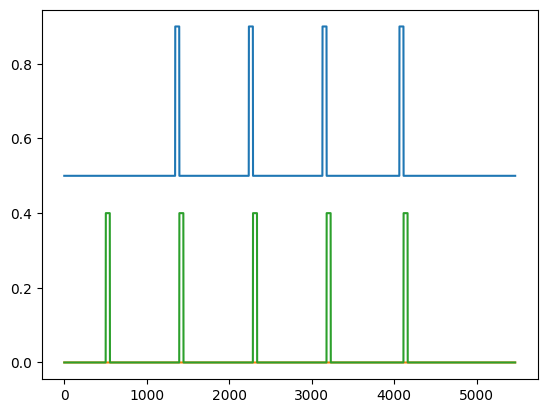

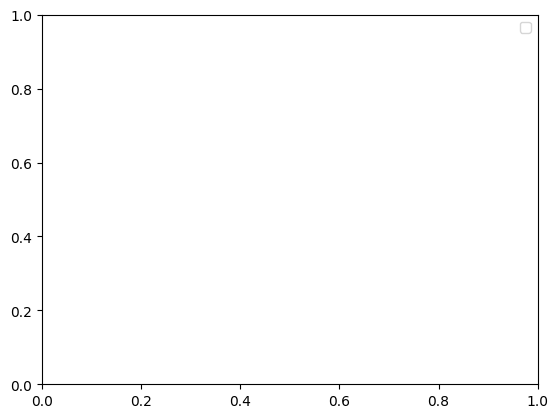

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    #period = 0.5+.15*2*(np.random.uniform()-.5);
    period = np.random.uniform(low = 0.2, high = 1.2)
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    
    a = np.where(fin != 0)
    
    a = np.array_split(a[0],5)
    
    
    #concatenate with time delay
    idx = a[4][0]
    fin = np.concatenate((fin[:idx], np.zeros((40, 1)), fin[idx:]), axis=0)
    fin = fin[:-40]
    #fin = np.concatenate((fin[:idx-200], fin[idx:], np.zeros((200,1))), axis=0)

    plt.plot(fin)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    
    
    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


Initializing...
Training network...
Batch 1 of 20, 20 trials: 
....................
Batch 2 of 20, 20 trials: 
....................
Batch 3 of 20, 20 trials: 
....................
Batch 4 of 20, 20 trials: 
....................
Batch 5 of 20, 20 trials: 
....................
Batch 6 of 20, 20 trials: 
....................
Batch 7 of 20, 20 trials: 
....................
Batch 8 of 20, 20 trials: 
....................
Batch 9 of 20, 20 trials: 
....................
Batch 10 of 20, 20 trials: 
....................
Batch 11 of 20, 20 trials: 
....................
Batch 12 of 20, 20 trials: 
....................
Batch 13 of 20, 20 trials: 
....................
Batch 14 of 20, 20 trials: 
....................
Batch 15 of 20, 20 trials: 
....................
Batch 16 of 20, 20 trials: 
....................
Batch 17 of 20, 20 trials: 
....................
Batch 18 of 20, 20 trials: 
....................
Batch 19 of 20, 20 trials: 
....................
Batch 20 of 20, 20 trials: 
..............

[(array([[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]),
  array([[0.5],
         [0.5],
         [0.5],
         ...,
         [0.5],
         [0.5],
         [0.5]]),
  array([[0.55403713],
         [0.55218794],
         [0.55455368],
         ...,
         [0.49043699],
         [0.4920947 ],
         [0.48931981]])),
 (array([[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]),
  array([[0.5],
         [0.5],
         [0.5],
         ...,
         [0.5],
         [0.5],
         [0.5]]),
  array([[0.49440794],
         [0.49738262],
         [0.49735351],
         ...,
         [0.50608596],
         [0.50550333],
         [0.50990545]])),
 (array([[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]),
  array([[0.5],
         [0.5],
         [0.5],
         ...,
         [0.5],
         [0.5],
         [0.5]]),
  array([[0.51330925],
         [0.5

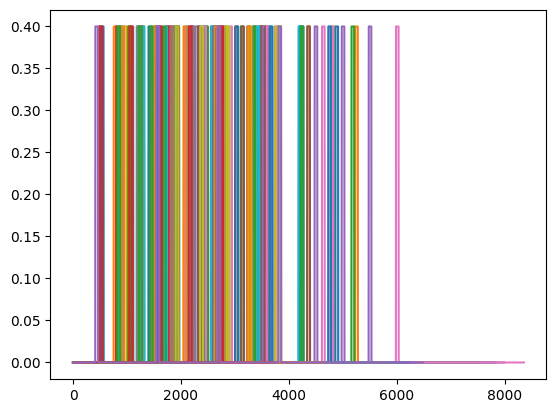

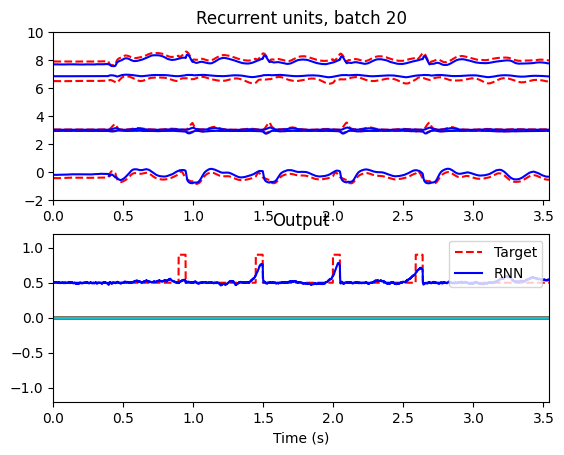

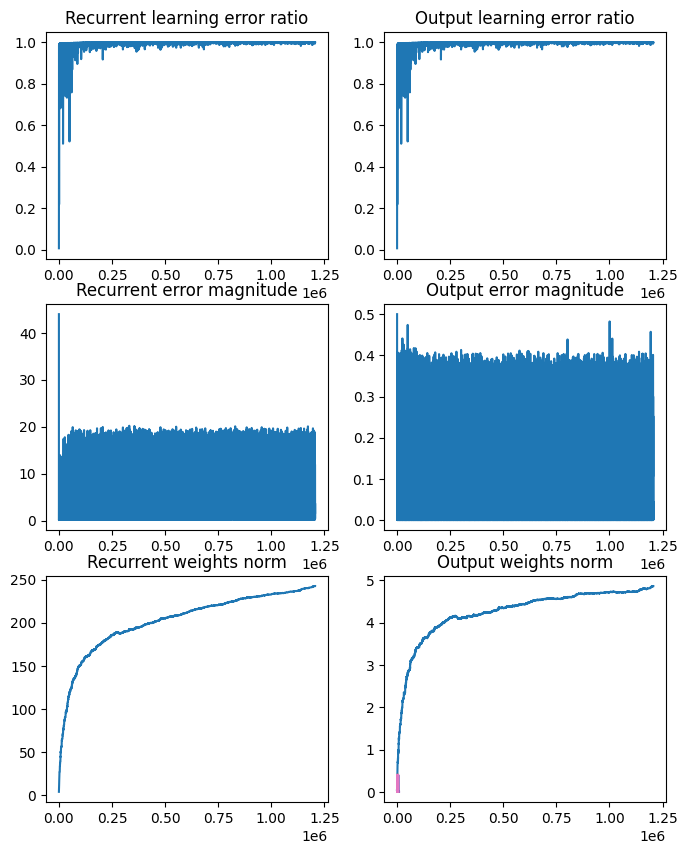

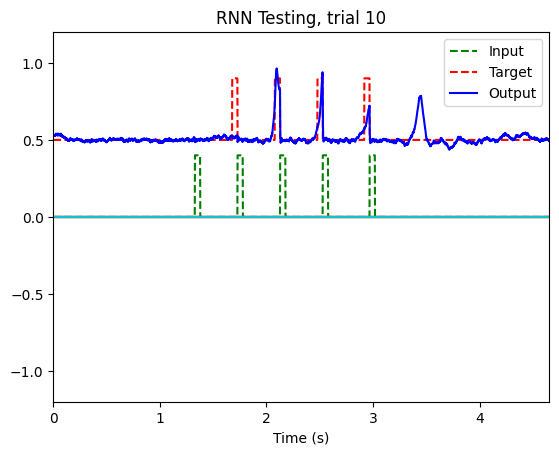

In [3]:
import importlib
import FF_Demo
importlib.reload(FF_Demo)
#%load_ext line_profiler

p = FF_Demo.create_parameters(dt=0.001)
p['g'] = 1.5 # From paper
p['ff_num_batches'] = 20
p['ff_trials_per_batch'] = 20
p['test_init_trials']=5
p['bias_scale'] = 0.5
p['ff_alpha'] = 1
p['network_size'] = 2000
p['noise_std'] = 0.01


(D_inputs, D_targs, D_hints) = random_pulses(dt=p['dt'])[0:3]

rnn = FF_Demo.RNN(p,1,1)

rnn.train(random_pulses, monitor_training=1)

#With line_profiler:
# %lprun -f rnn.train rnn.train(fullforce_oscillation_test, monitor_training=1)


rnn.test(specific_pulse)

In [4]:

import pickle

filename = "cosyne--2000-0.2-1.2-20-20-0.5"
pickle.dump(rnn, open(filename, 'wb'))
'''
## error_to_plot = []
for item in np.arange(0.2,0.8,0.05):
    x = rnn.test(specific_pulse, period = item)
    #error_to_plot.append(x[0][0])
        #print(len(x[0][2]))
    ftarg = x[0][1]

    fout = x[0][2]

    a = np.where(ftarg == np.max(ftarg))
    a = np.array_split(a[0],5)

    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)

    plt.plot(x[0][0])
    plt.plot(fout)
    plt.plot(ftarg)

    max_val = np.max(fout[idx-200:idx+200])

    max_out_near_predict = np.where(fout[idx-200:idx+200] == max_val)
    idx2 = max_out_near_predict[0][0]+ idx-200
    #print(np.max(fout[idx-200:idx+200]))
    plt.scatter(idx+20, 0.75,4)
    plt.scatter(idx - 200 + max_out_near_predict[0],0.75,4)
    time_from_target = 0.001*((idx-200+max_out_near_predict[0])-(idx+20))

    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    
    
#print(fout[idx2][0])
#print(round(0.25+max_val/2,8))
#Ppt(np.abs(fout[idx2-200:idx2] - (0.25+max_val/2)).argmin())
    pulse_left = idx2 -200 + np.abs(fout[idx2-200:idx2] - (0.25+max_val/2)).argmin()
    pulse_right = idx2 + np.abs(fout[idx2:idx2+200] - (0.25+max_val/2)).argmin()

    plt.scatter(pulse_left, 0.25+max_val/2,4)
    plt.scatter(pulse_right, 0.25+max_val/2,4)
#plt.plot(pulse_left,0.25+max_val/2,pulse_right, 0.25+max_val/2,c='k')
#pulse_right = np.where(fout[idx2:idx2+200] == (round(0.25+max_val/2,8)))


#print(pulse_left)
#print(pulse_right)
    print(f"The width of the predicted pulse at half-max is {100*abs(pulse_left-pulse_right)/40}% the size of input")



#plt.figure()
#plt.plot(np.arange(0.2,0.8,0.05), error_to_plot)
#plt.show()
#print(error_to_plot

'''

'\n## error_to_plot = []\nfor item in np.arange(0.2,0.8,0.05):\n    x = rnn.test(specific_pulse, period = item)\n    #error_to_plot.append(x[0][0])\n        #print(len(x[0][2]))\n    ftarg = x[0][1]\n\n    fout = x[0][2]\n\n    a = np.where(ftarg == np.max(ftarg))\n    a = np.array_split(a[0],5)\n\n    idx = a[4][0] + abs(a[4][0] -  a[3][0])\n    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)\n\n    plt.plot(x[0][0])\n    plt.plot(fout)\n    plt.plot(ftarg)\n\n    max_val = np.max(fout[idx-200:idx+200])\n\n    max_out_near_predict = np.where(fout[idx-200:idx+200] == max_val)\n    idx2 = max_out_near_predict[0][0]+ idx-200\n    #print(np.max(fout[idx-200:idx+200]))\n    plt.scatter(idx+20, 0.75,4)\n    plt.scatter(idx - 200 + max_out_near_predict[0],0.75,4)\n    time_from_target = 0.001*((idx-200+max_out_near_predict[0])-(idx+20))\n\n    if time_from_target < 0: \n        print(f"The predicted pulse peak is {abs(time_from_target)} seconds

In [13]:
import pickle

filename = "model20-early-2000-full-period-20-20-0.5"
pickle.dump(rnn, open(filename, 'wb'))

Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (13,) + inhomogeneous part.

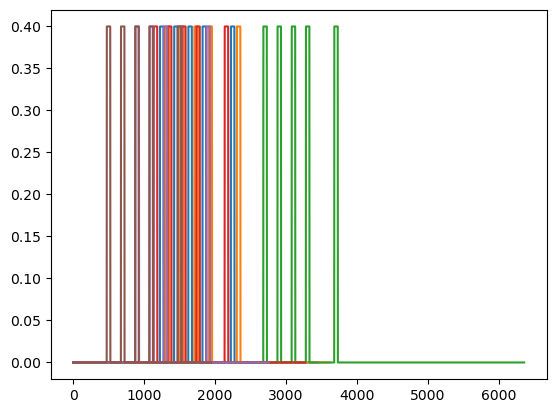

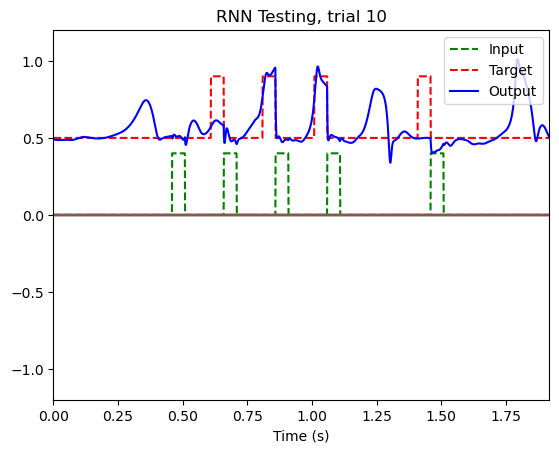

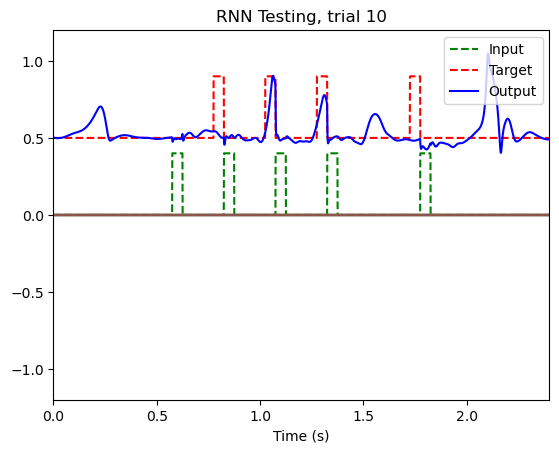

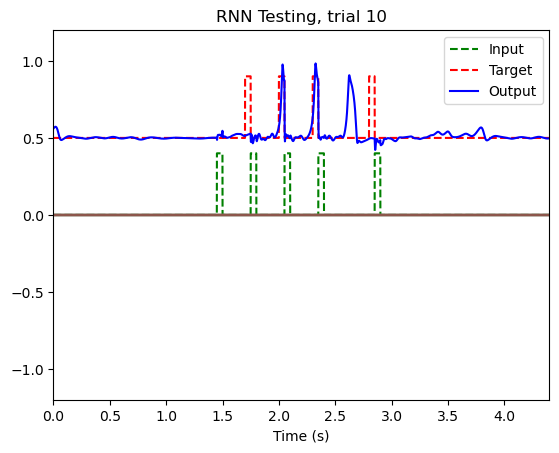

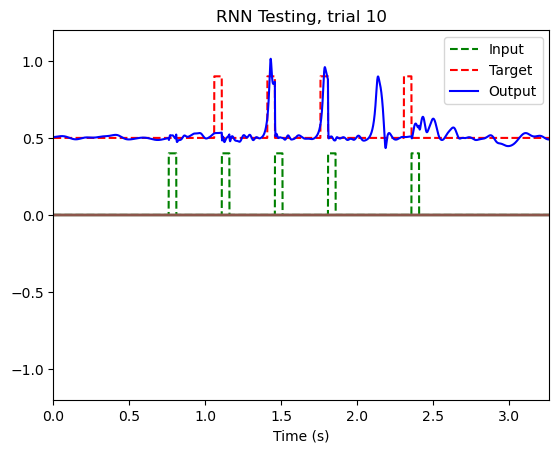

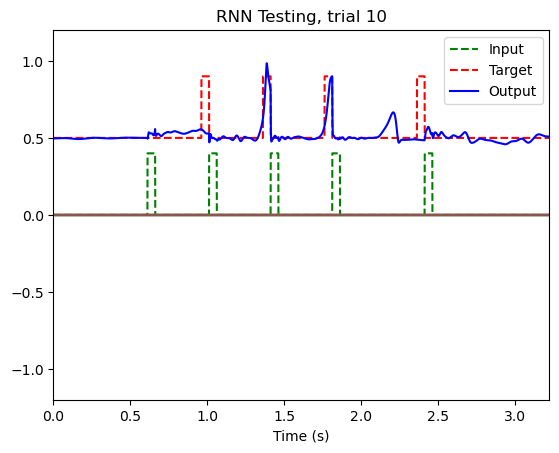

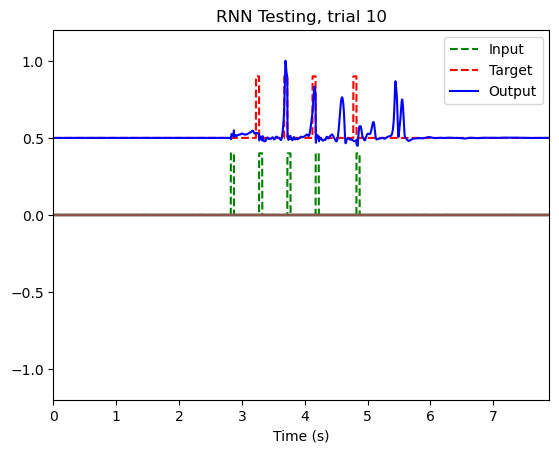

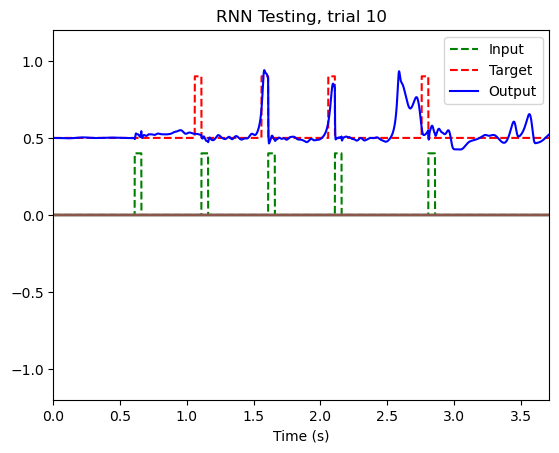

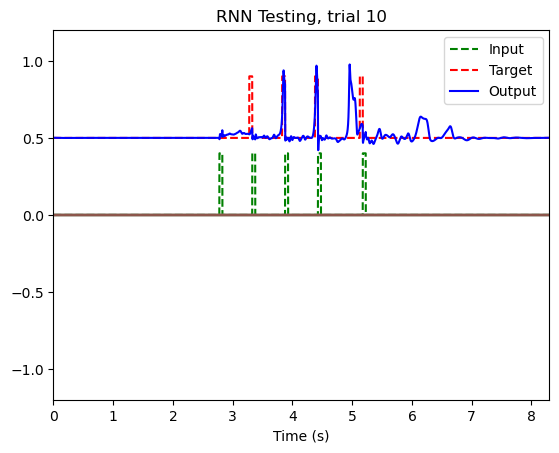

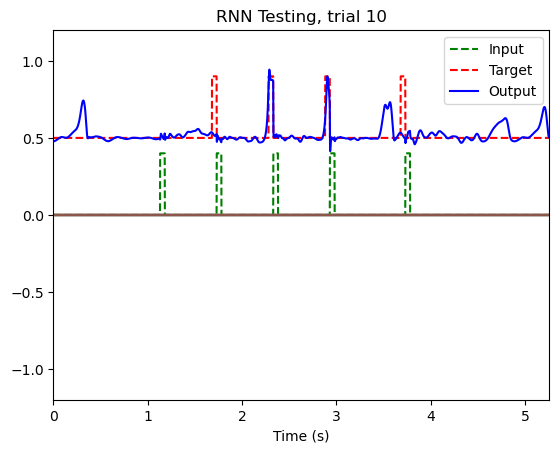

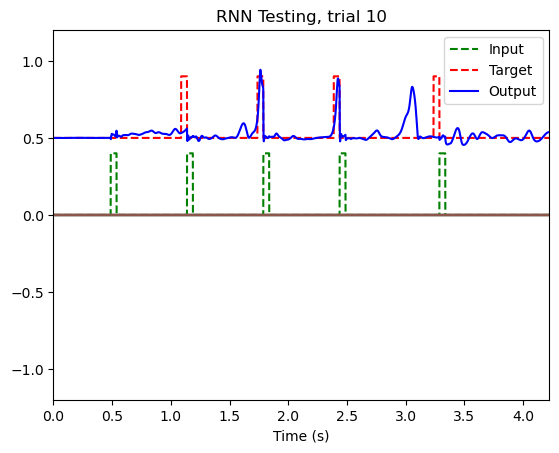

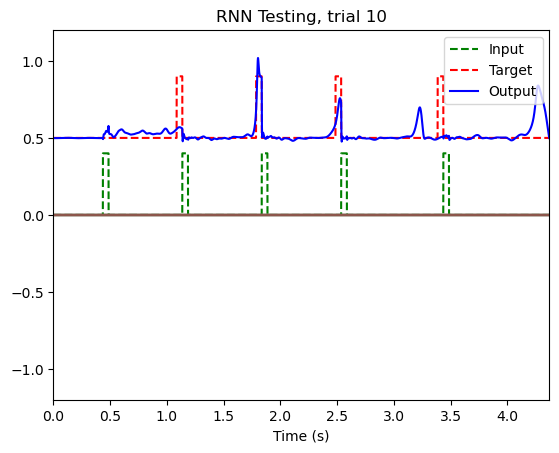

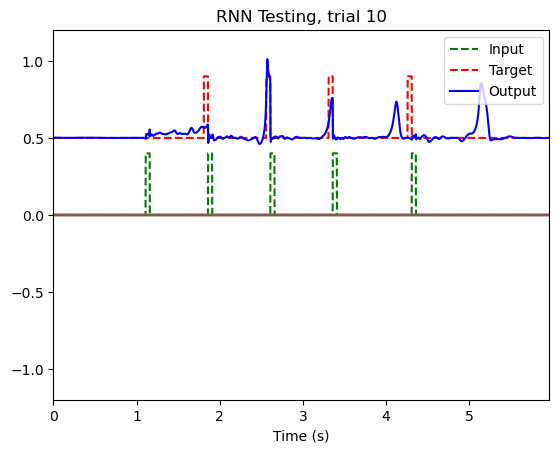

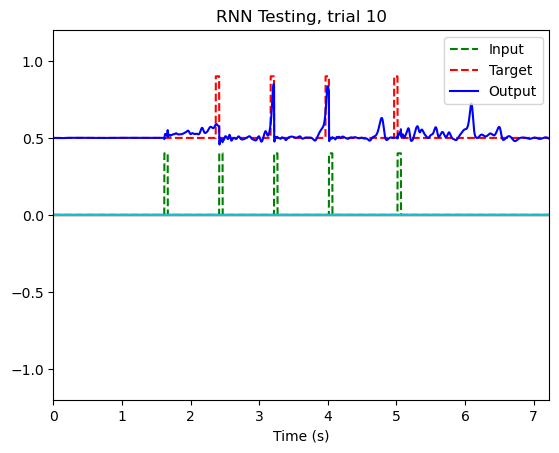

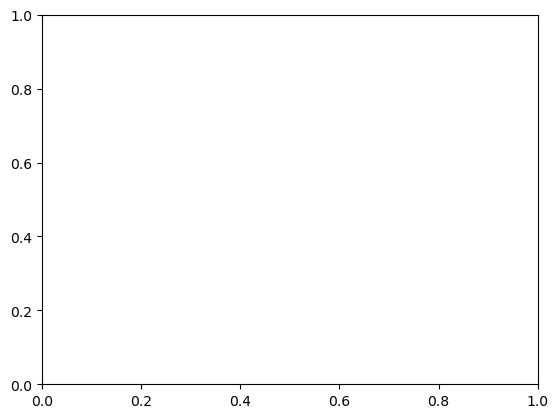

In [10]:
import pickle
import numpy as np
loaded_model = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))
error_to_plot = []
for item in np.arange(0.2,0.8,0.05):
    x = loaded_model.test(specific_pulse, period = item)
    error_to_plot.append(x[0][0])

plt.figure()
plt.plot(np.arange(0.2,0.8,0.05), error_to_plot)
plt.show()
#print(error_to_plot)

Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........
Initializing.....
Testing: 10 trials
..........


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (13,) + inhomogeneous part.

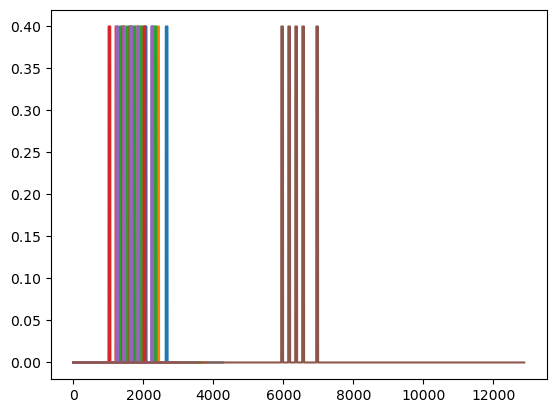

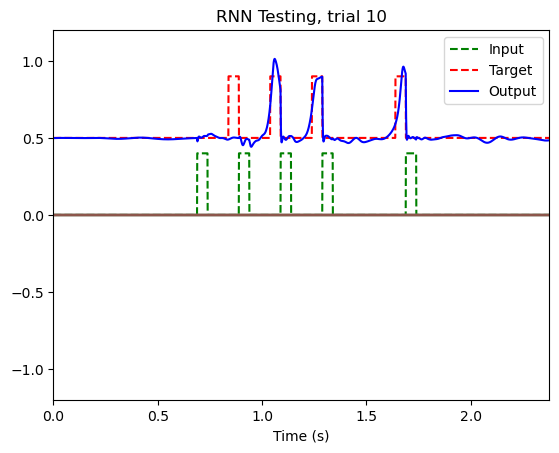

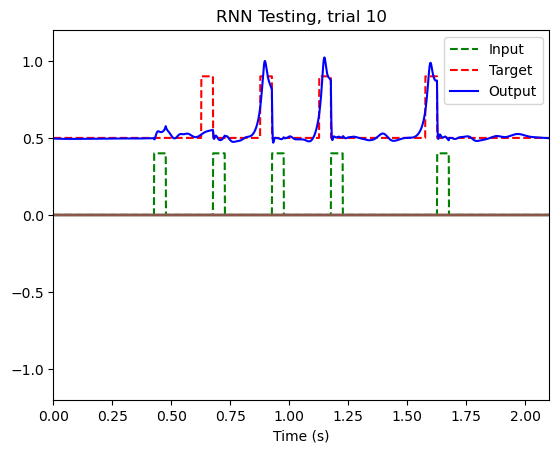

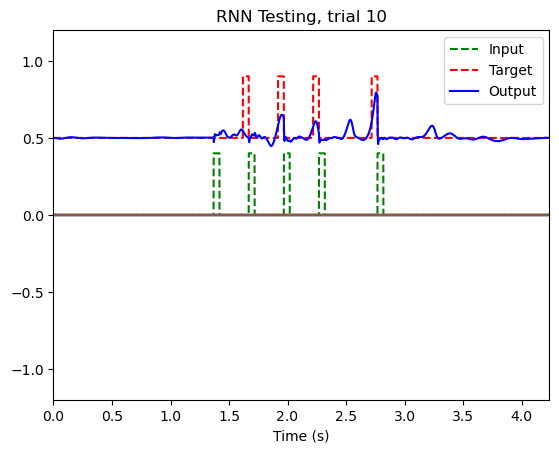

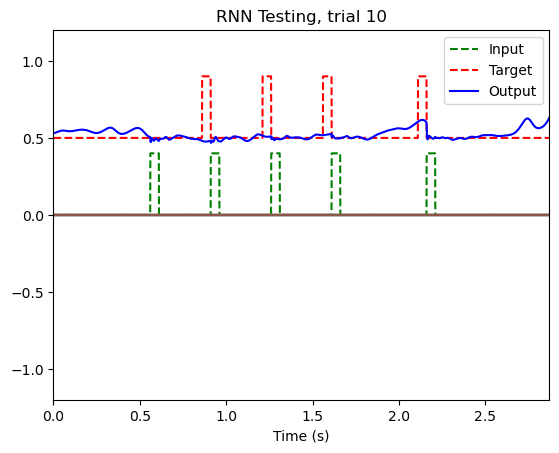

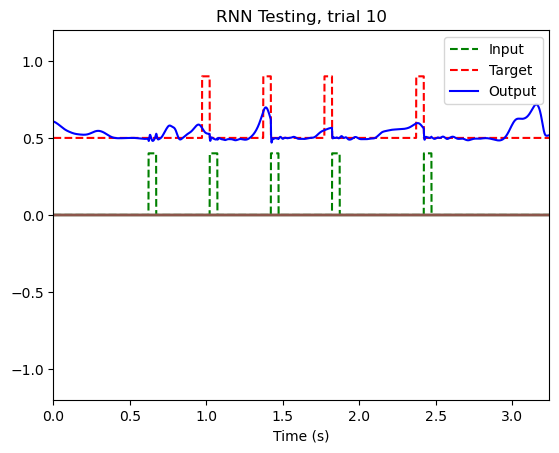

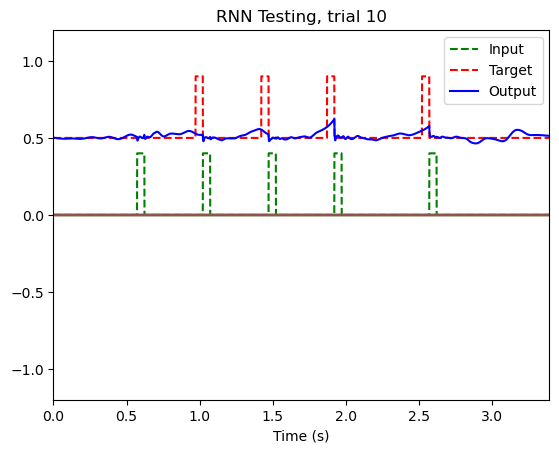

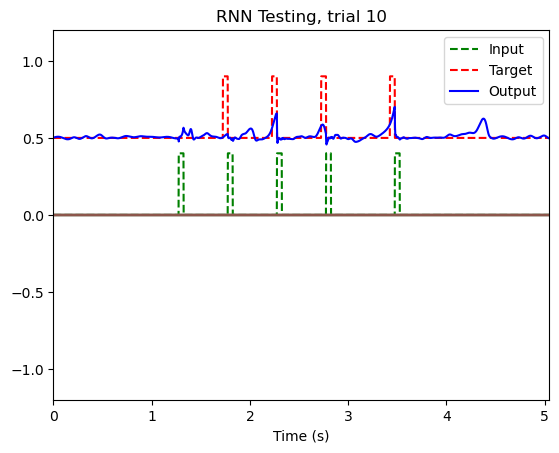

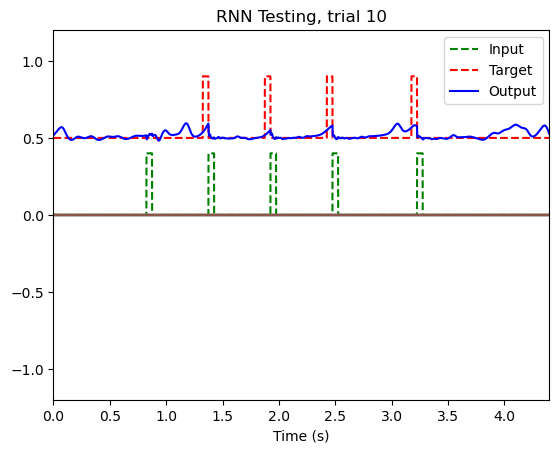

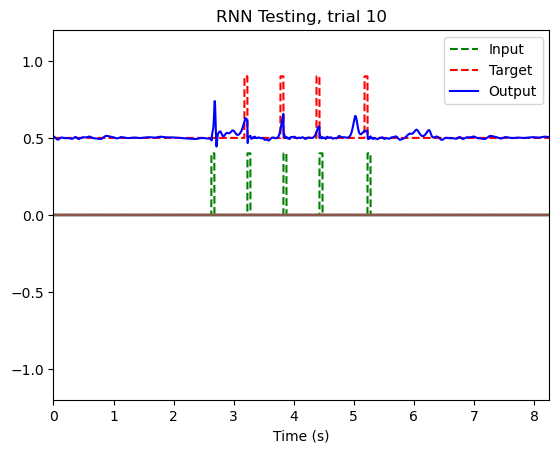

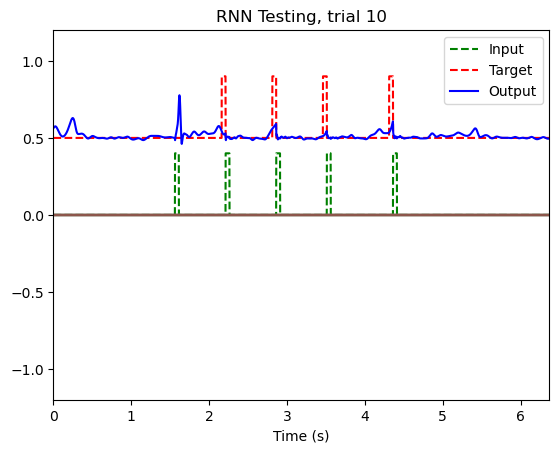

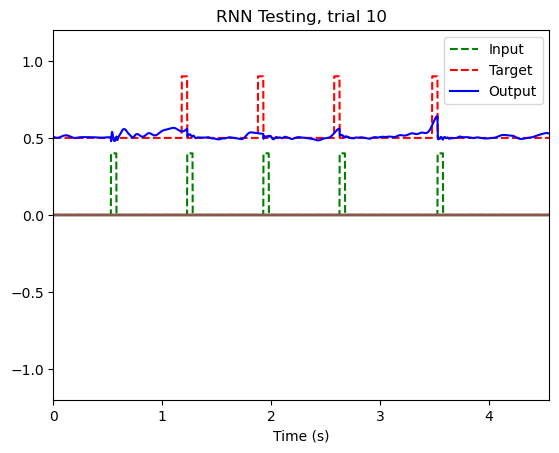

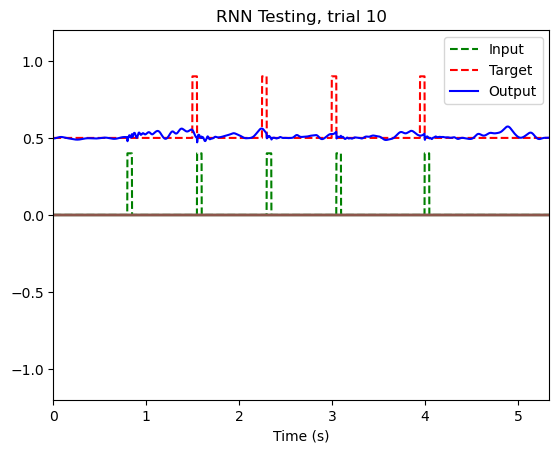

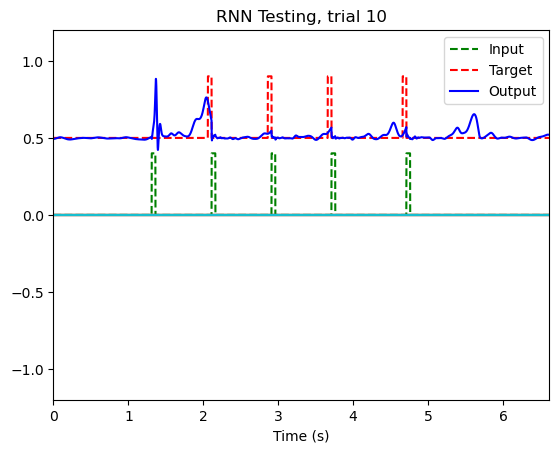

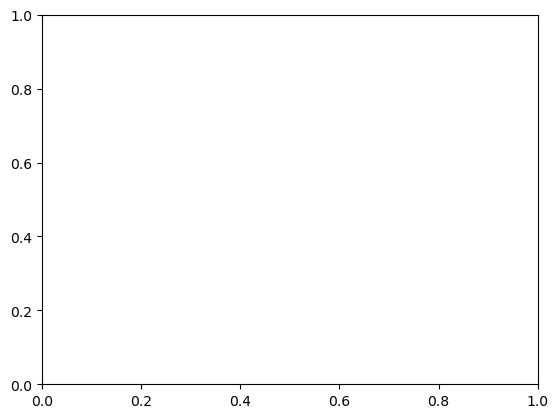

In [8]:
import pickle
import numpy as np
loaded_model = pickle.load(open("model20-delay-2000-full-period-20-20-0.5",'rb'))
error_to_plot = []
for item in np.arange(0.2,0.8,0.05):
    x = loaded_model.test(specific_pulse, period = item)
    error_to_plot.append(x[0][0])

plt.figure()
plt.plot(np.arange(0.2,0.8,0.05), error_to_plot)
plt.show()
#print(error_to_plot)